28155 rpm mean, bin = 18.5 rpm


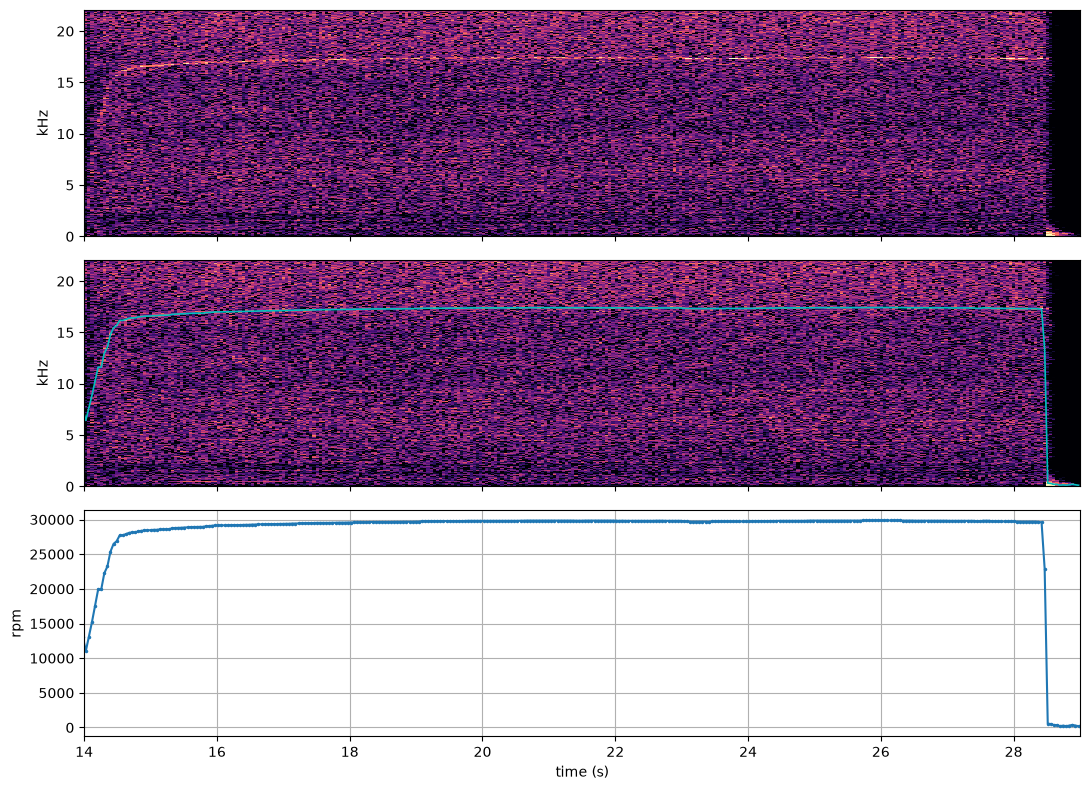

In [107]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt


WAV, BLADES = "C:\\Users\\Martin\\Active\\otp-sizing\\data\\OT-2\\20260701-111_Canon_700D.wav", 35
N, H = 4096, 2048          # window, hop
JUMP_HZ, MIN_DB = 400, 8   # max ridge move per frame, tone-lost threshold

# load
fs, x = wavfile.read(WAV)
x = x.astype(float)
if x.ndim > 1: x = x[:, 0]
x /= np.abs(x).max()

# stft
win = np.hanning(N)
nframes = 1 + (len(x) - N)//H
S = np.empty((N//2 + 1, nframes))
for i in range(nframes):
    S[:, i] = np.abs(np.fft.rfft(x[i*H : i*H+N] * win))
f = np.fft.rfftfreq(N, 1/fs)
t = (np.arange(nframes)*H + N/2) / fs

# whiten: dB above each bin's own background
W = 20*np.log10(S + 1e-12)
W -= np.median(W, axis=1, keepdims=True)
# W -= np.median(W, axis=0, keepdims=True)

line = np.where(W.max(axis=0) > 12, f[W.argmax(axis=0)], np.nan)
T0, T1 = 14.0, 29.0                       # read off your plot
line[(t < T0) | (t > T1)] = np.nan

import pandas as pd
line = pd.Series(line).rolling(9, center=True, min_periods=3).median().to_numpy()

rpm = 60 * line / BLADES

# plot
fig, (a0, a1, a2) = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
a0.pcolormesh(t, f/1000, W, shading="nearest", cmap="magma", vmin=0, vmax=25)
a1.pcolormesh(t, f/1000, W, shading="nearest", cmap="magma", vmin=0, vmax=25)
a1.plot(t, line/1000, "c", lw=1.2)
a1.set_ylabel("kHz")
a0.set_ylabel("kHz")
a2.plot(t, rpm, ".-", ms=3)
a2.set_ylabel("rpm"); a2.set_xlabel("time (s)"); a2.grid()
a1.set_xlim(T0, T1)
plt.tight_layout()

print(f"{np.nanmean(rpm):.0f} rpm mean, bin = {(f[1]-f[0])*60/BLADES:.1f} rpm")

Text(0, 0.5, 'dB above background')

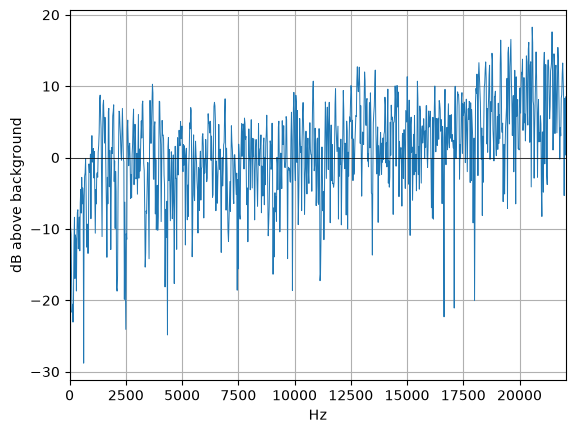

In [48]:
m = np.argmin(np.abs(t - 14.0))
plt.plot(f, W[:, m], lw=0.7); plt.axhline(0, color='k', lw=0.5)
plt.xlim(0, fs/2); plt.grid(); plt.xlabel("Hz"); plt.ylabel("dB above background")

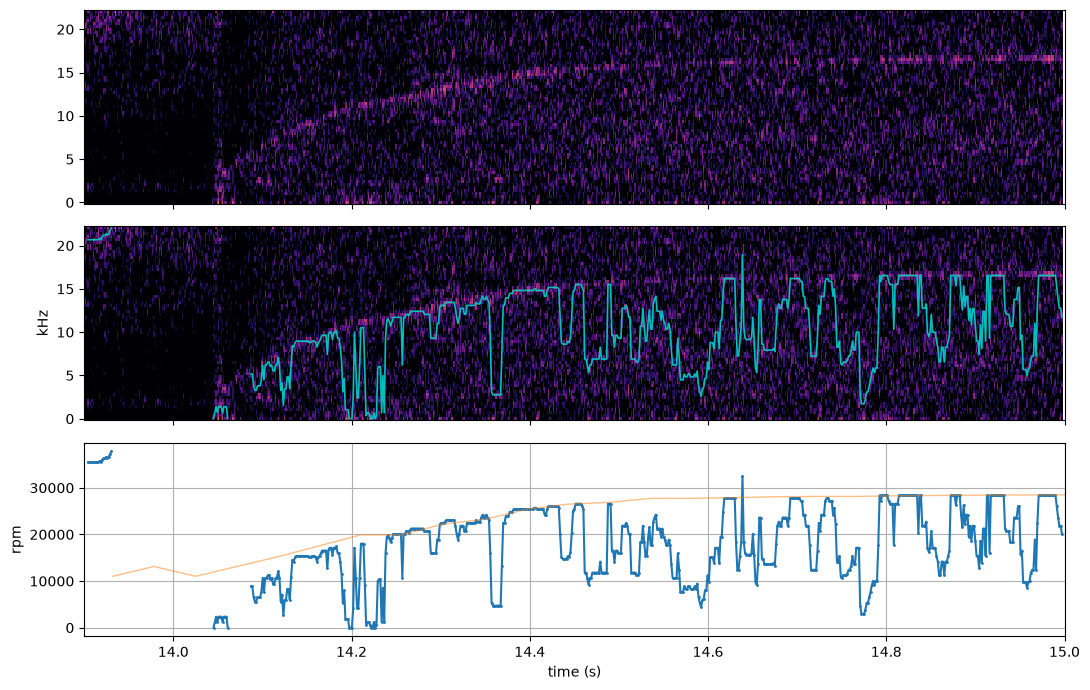

In [116]:
TA, TB = 13.9, 15.0
N2, H2 = 128, 64                       # 23 ms window, frame every 2.9 ms

xs = x[int(TA*fs):int(TB*fs)]
win2 = np.hanning(N2)
nf2 = 1 + (len(xs) - N2)//H2
S2 = np.empty((N2//2 + 1, nf2))
for i in range(nf2):
    S2[:, i] = np.abs(np.fft.rfft(xs[i*H2 : i*H2+N2] * win2))
f2 = np.fft.rfftfreq(N2, 1/fs)
t2 = TA + (np.arange(nf2)*H2 + N2/2)/fs

W2 = 20*np.log10(S2 + 1e-12)
W2 -= np.median(W2, axis=1, keepdims=True)

line2 = np.where(W2.max(axis=0) > 8, f2[W2.argmax(axis=0)], np.nan)
line2 = pd.Series(line2).rolling(9, center=True, min_periods=5).median().to_numpy()
rpm2 = 60 * line2 / BLADES

fig, (b0, b1, b2) = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
b0.pcolormesh(t2, f2/1000, W2, shading="nearest", cmap="magma", vmin=0, vmax=25)
b1.pcolormesh(t2, f2/1000, W2, shading="nearest", cmap="magma", vmin=0, vmax=25)
b1.plot(t2, line2/1000, "c", lw=1.2); b1.set_ylabel("kHz")
b2.plot(t2, rpm2, ".-", ms=2); b2.set_ylabel("rpm"); b2.set_xlabel("time (s)"); b2.grid()
b2.plot(t, rpm, lw=1, alpha=0.5)          # your N=4096 result for comparison
plt.xlim(TA, TB)
plt.tight_layout()